In [2]:
%load_ext autoreload
%autoreload 2

import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np

import torch_svd as tsvd
import torch_custom as tc
from torch.utils.data import DataLoader
from torch.nn.utils import parameters_to_vector, vector_to_parameters

from tqdm import tqdm
from collections import defaultdict
import matplotlib.pyplot as plt
import time
import json

torch.set_float32_matmul_precision('high')

device = torch.device('cuda' if torch.cuda.is_available() else ('mps' if torch.backends.mps.is_available() else 'cpu'))
print(f"Using device: {device}")

Using device: cuda


# Define Small ResNet Architecture

In [3]:
class BasicBlock(nn.Module):
    def __init__(self, in_channels, out_channels, stride=1):
        super().__init__()
        self.conv1 = nn.Conv2d(in_channels, out_channels, kernel_size=3, stride=stride, padding=1, bias=False)
        self.bn1 = tc.BatchNorm2d(out_channels)
        self.conv2 = nn.Conv2d(out_channels, out_channels, kernel_size=3, stride=1, padding=1, bias=False)
        self.bn2 = tc.BatchNorm2d(out_channels)
        
        self.shortcut = nn.Sequential()
        if stride != 1 or in_channels != out_channels:
            self.shortcut = nn.Sequential(
                nn.Conv2d(in_channels, out_channels, kernel_size=1, stride=stride, bias=False),
                tc.BatchNorm2d(out_channels)
            )
    
    def forward(self, x):
        out = F.relu(self.bn1(self.conv1(x)))
        out = self.bn2(self.conv2(out))
        out += self.shortcut(x)
        out = F.relu(out)
        return out

class SmallResNet(nn.Module):
    def __init__(self, num_classes=10, width=16):
        super().__init__()
        self.conv1 = nn.Conv2d(3, width, kernel_size=3, stride=1, padding=1, bias=False)
        self.bn1 = tc.BatchNorm2d(width)
        
        self.layer1 = self._make_layer(width, width, num_blocks=2, stride=1)
        self.layer2 = self._make_layer(width, width*2, num_blocks=2, stride=2)
        self.layer3 = self._make_layer(width*2, width*4, num_blocks=2, stride=2)
        
        self.avg_pool = nn.AdaptiveAvgPool2d((1, 1))
        self.fc = nn.Linear(width*4, num_classes)
    
    def _make_layer(self, in_channels, out_channels, num_blocks, stride):
        layers = [BasicBlock(in_channels, out_channels, stride)]
        for _ in range(1, num_blocks):
            layers.append(BasicBlock(out_channels, out_channels, stride=1))
        return nn.Sequential(*layers)
    
    def forward(self, x):
        out = F.relu(self.bn1(self.conv1(x)))
        out = self.layer1(out)
        out = self.layer2(out)
        out = self.layer3(out)
        out = self.avg_pool(out)
        out = out.view(out.size(0), -1)
        out = self.fc(out)
        return out

# Load CIFAR-10 Dataset

In [4]:
from torchvision import datasets, transforms

# CIFAR-10 normalization values
transform_train = transforms.Compose([
    transforms.RandomCrop(32, padding=4),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize((0.4914, 0.4822, 0.4465), (0.2023, 0.1994, 0.2010)),
])

transform_test = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.4914, 0.4822, 0.4465), (0.2023, 0.1994, 0.2010)),
])

train_dataset = datasets.CIFAR10(root='./datasets', train=True, download=True, transform=transform_train)
test_dataset = datasets.CIFAR10(root='./datasets', train=False, download=True, transform=transform_test)

# Model configuration
batch_size = 1024
width = 8  # Width multiplier for ResNet
num_classes = 10

# Train Normal Supervised Model

In [5]:
model_sup = SmallResNet(num_classes=num_classes, width=width).to(device)
print(f"Model has {sum(p.numel() for p in model_sup.parameters())} parameters")

# Reduced batch sizes for SVD training
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, num_workers=2)
test_loader = DataLoader(test_dataset, batch_size=256, shuffle=False, num_workers=2)

optimizer = torch.optim.Adam(model_sup.parameters(), lr=1e-3)
loss_fn = nn.CrossEntropyLoss()

num_epochs = 1
losses_direct = defaultdict(list)

for epoch in range(num_epochs):
    print(f"Epoch {epoch+1}/{num_epochs}")
    epoch_losses = defaultdict(list)
    
    model_sup.train()
    for xb, yb in tqdm(train_loader, desc="Training"):
        xb, yb = xb.to(device), yb.to(device)
        optimizer.zero_grad()
        ypred = model_sup(xb)
        loss = loss_fn(ypred, yb)
        loss.backward()
        optimizer.step()
        epoch_losses['train'].append(loss.item())
    
    model_sup.eval()
    with torch.no_grad():
        correct = 0
        total = 0
        for xb, yb in tqdm(test_loader, desc="Validation"):
            xb, yb = xb.to(device), yb.to(device)
            ypred = model_sup(xb)
            loss = loss_fn(ypred, yb)
            epoch_losses['val'].append(loss.item())
            
            _, predicted = ypred.max(1)
            total += yb.size(0)
            correct += predicted.eq(yb).sum().item()
        
        accuracy = 100. * correct / total
        print(f"Validation Accuracy: {accuracy:.2f}%")
    
    losses_direct['train_batch'].extend(epoch_losses['train'])
    losses_direct['val_batch'].extend(epoch_losses['val'])
    for k, v in epoch_losses.items():
        losses_direct[k].append(np.mean(v))
    
    print(f"Train Loss: {losses_direct['train'][-1]:.4f}, Val Loss: {losses_direct['val'][-1]:.4f}")
with open(f"cifar10_direct_losses.pt", "w") as f:
    json.dump(losses_direct, f)

Model has 44370 parameters
Epoch 1/1


Validation: 100%|██████████| 40/40 [00:00<00:00, 40.89it/s]


Validation Accuracy: 30.82%
Train Loss: 1.9057, Val Loss: 1.8702


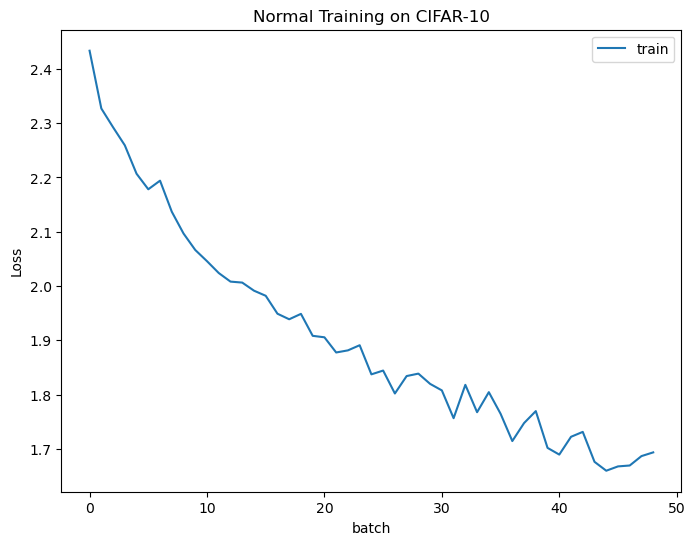

In [6]:
with open(f"cifar10_direct_losses.pt", "r") as f:
    losses_direct = json.load(f)

plt.figure(figsize=(8,6))
plt.plot(losses_direct['train_batch'], label='train')
plt.xlabel('batch')
plt.ylabel('Loss')
plt.legend()
plt.title('Normal Training on CIFAR-10')
plt.show()

# SVD Optimizer Training (New Framework)

In [8]:
model_svd = SmallResNet(num_classes=num_classes, width=width).to(device)
print(f"Model has {sum(p.numel() for p in model_svd.parameters())} parameters")

loss_fn_svd = nn.CrossEntropyLoss(reduction='none')
loss_lambda = lambda pred, y: loss_fn_svd(pred, y).squeeze()

# SVD optimizer parameters - adjusted for larger model
lr_svd = 0.05
k_svd = batch_size // 1.5   # Rank for SVD
rtol = 1e-3
opt_svd = tsvd.SVDOptimizer(lr=lr_svd, k=k_svd, rtol=rtol)
#opt_svd = tsvd.SVDOptimizerRMSprop(lr=lr_svd, k=k_svd, rtol=rtol)
fmodel_svd = tsvd.FunctionalModelJac(model_svd, loss_lambda, opt_svd)

num_epochs = 1
train_loader_svd = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, num_workers=2, drop_last=True)
test_loader_svd = DataLoader(test_dataset, batch_size=256, shuffle=False, num_workers=2)

losses_svd = defaultdict(list)
batch_losses_svd = defaultdict(list)

# Ensure all computations are done without gradients
with torch.no_grad():
    for epoch in range(num_epochs):
        print(f"Epoch {epoch+1}/{num_epochs}")
        epoch_losses = defaultdict(list)
        
        for xb, yb in tqdm(train_loader_svd, desc="Training (SVD)"):
            xb, yb = xb.to(device), yb.to(device)
            batch = (xb, yb)
            losses, batch_info = fmodel_svd.train_step(batch)
            #gradients, losses = fmodel_svd.batch_gradient(params_svd, batch)
            #update, extra_info = opt_svd.compute_update(gradients, losses)
            #params_svd = params_svd + update
            #fmodel_svd.params = params_svd
            
            epoch_losses['train'].append(losses.mean().item())
            batch_losses_svd['train'].append(losses.mean().cpu().numpy())
            for k in batch_info:
                batch_losses_svd["train_"+k].append(batch_info[k])
        
        correct = 0
        total = 0
        for xb, yb in tqdm(test_loader_svd, desc="Validation (SVD)"):
            xb, yb = xb.to(device).detach(), yb.to(device).detach()
            ypred = fmodel_svd.evaluate(xb)
            loss = loss_lambda(ypred, yb).mean()
            epoch_losses['val'].append(loss.item())
            batch_losses_svd['val'].append(loss.item())
            
            _, predicted = ypred.max(1)
            total += yb.size(0)
            correct += predicted.eq(yb).sum().item()
        
        accuracy = 100. * correct / total
        print(f"Validation Accuracy: {accuracy:.2f}%")

        losses_svd['train_batch'].extend(epoch_losses['train'])
        losses_svd['val_batch'].extend(epoch_losses['val'])
        for k_name, v in epoch_losses.items():
            losses_svd[k_name].append(np.mean(v))
        
        print(f"Train Loss: {losses_svd['train'][-1]:.4f}, Val Loss: {losses_svd['val'][-1]:.4f}")
with open(f"cifar10_svd_losses.pt", "w") as f:
    json.dump(losses_svd, f)

Model has 44370 parameters
Epoch 1/1


Training (SVD):   0%|          | 0/48 [00:03<?, ?it/s]


OutOfMemoryError: CUDA out of memory. Tried to allocate 8.00 GiB. GPU 0 has a total capacity of 79.25 GiB of which 1.90 GiB is free. Including non-PyTorch memory, this process has 49.72 GiB memory in use. Process 1075600 has 27.61 GiB memory in use. Of the allocated memory 49.17 GiB is allocated by PyTorch, and 46.16 MiB is reserved by PyTorch but unallocated. If reserved but unallocated memory is large try setting PYTORCH_CUDA_ALLOC_CONF=expandable_segments:True to avoid fragmentation.  See documentation for Memory Management  (https://pytorch.org/docs/stable/notes/cuda.html#environment-variables)

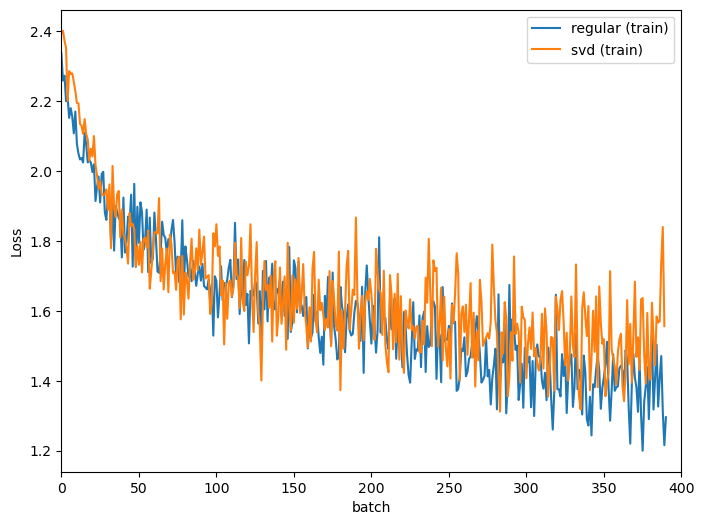

In [27]:
plt.figure(figsize=(8,6))
plt.plot(losses_direct['train_batch'], label='regular (train)',color="C0")
plt.plot(losses_svd['train_batch'], label='svd (train)',color="C1")
plt.xlabel('batch')
plt.ylabel('Loss')
#plt.yscale('log')
plt.xlim(0,400)
plt.legend()
plt.show()

IndexError: index 6 is out of bounds for axis 0 with size 6

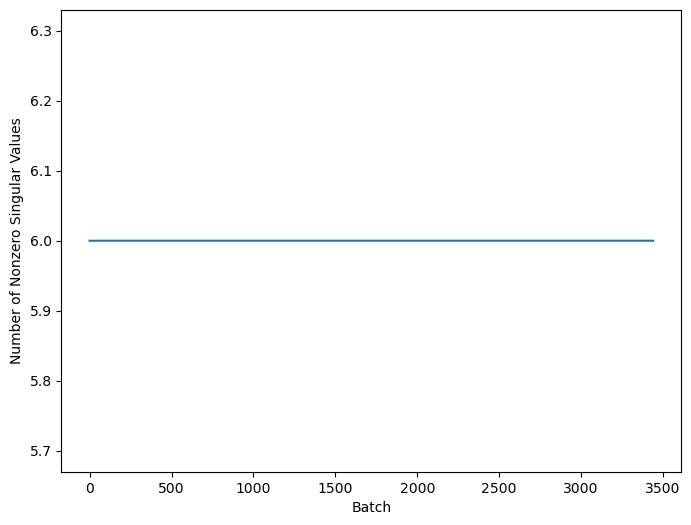

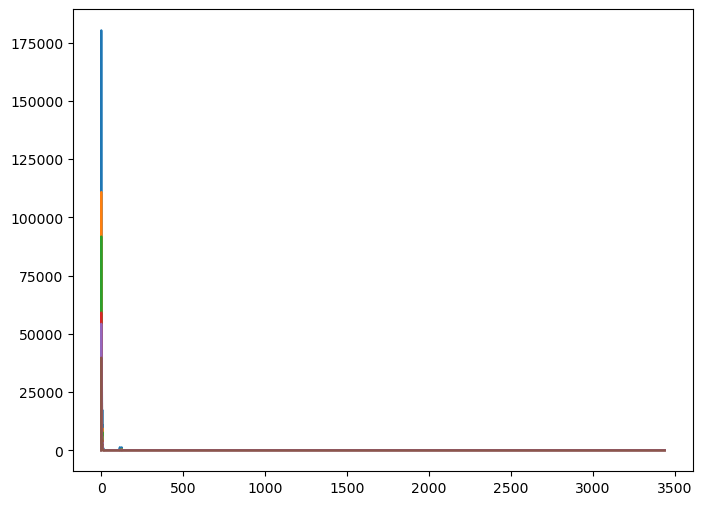

In [27]:
plt.figure(figsize=(8,6))
plt.plot(batch_losses_svd['train_num_svs'], label='num_svs')
plt.xlabel('Batch')
plt.ylabel('Number of Nonzero Singular Values')

plt.figure(figsize=(8,6))
n_batches = len(batch_losses_svd['train_num_svs'])
for i in range(10):
    plt.plot(np.arange(n_batches), [svs[i] for svs in batch_losses_svd['train_singular_values']])
plt.xlabel('Batch')
plt.ylabel('Singular Values')
plt.yscale('log')

# Compare Normal vs SVD Training

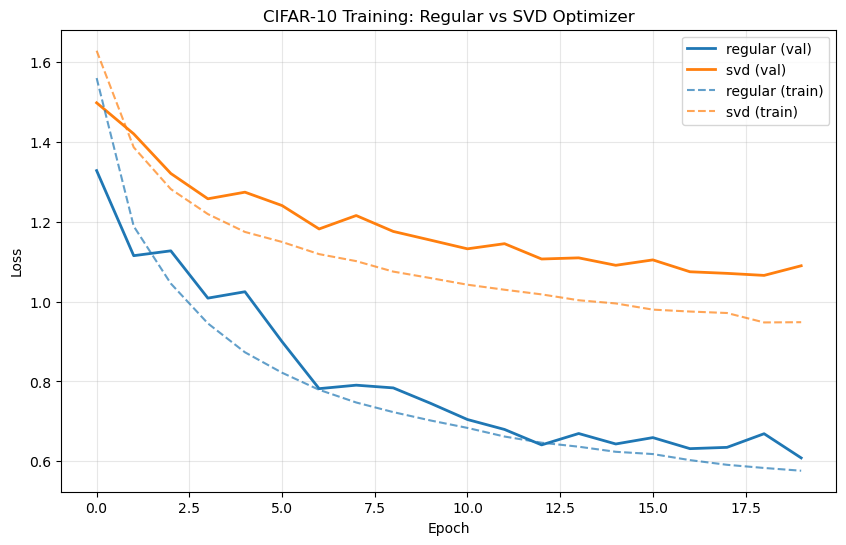

In [36]:
plt.figure(figsize=(10,6))
plt.plot(losses_direct['val'], label='regular (val)', color="C0", linewidth=2)
plt.plot(losses_svd['val'], label='svd (val)', color="C1", linewidth=2)
plt.plot(losses_direct['train'], label='regular (train)', color="C0", linestyle='dashed', alpha=0.7)
plt.plot(losses_svd['train'], label='svd (train)', color="C1", linestyle='dashed', alpha=0.7)
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('CIFAR-10 Training: Regular vs SVD Optimizer')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

# Timing Analysis

In [ ]:
import time
import numpy as np

def _device_sync():
    if torch.cuda.is_available():
        torch.cuda.synchronize()
    elif hasattr(torch.backends, "mps") and torch.backends.mps.is_available():
        torch.mps.synchronize()

def time_svd_epoch(fmodel_svd, opt_svd, params_svd, train_loader, max_batches=None):
    stats = {"jacobian": [], "update": [], "apply": [], "pinv_total": []}
    import torch_svd as tsvd
    last_pinv_time = {"total": None}
    _orig_pinv = tsvd.pinv
    
    def _timed_pinv(*args, **kwargs):
        _device_sync()
        t0 = time.perf_counter()
        out = _orig_pinv(*args, **kwargs)
        _device_sync()
        elapsed = time.perf_counter() - t0
        last_pinv_time["total"] = elapsed
        return out
    
    tsvd.pinv = _timed_pinv
    
    def _record(name, val):
        stats[name].append(val)
    
    batch_iter = enumerate(train_loader)
    if max_batches is None:
        max_batches = len(train_loader)
    
    for bi, (xb, yb) in batch_iter:
        if bi >= max_batches:
            break
        xb, yb = xb.to(device), yb.to(device)
        batch = (xb, yb)
        
        _device_sync()
        t0 = time.perf_counter()
        gradients, losses = fmodel_svd.batch_gradient(params_svd, batch)
        _device_sync()
        jac_t = time.perf_counter() - t0
        _record("jacobian", jac_t)
        
        _device_sync()
        t0 = time.perf_counter()
        update = opt_svd.compute_update(gradients, losses)
        _device_sync()
        upd_t = time.perf_counter() - t0
        _record("update", upd_t)
        
        if last_pinv_time["total"] is not None:
            _record("pinv_total", last_pinv_time["total"])
            last_pinv_time["total"] = None
        
        _device_sync()
        t0 = time.perf_counter()
        params_svd = params_svd + update
        fmodel_svd.params = params_svd
        _device_sync()
        app_t = time.perf_counter() - t0
        _record("apply", app_t)
    
    tsvd.pinv = _orig_pinv
    
    def _summ(d):
        a = np.array(d) if len(d) else np.array([0.0])
        return dict(mean=a.mean(), std=a.std(), min=a.min(), max=a.max(), count=len(a))
    
    summary = {k: _summ(v) for k, v in stats.items()}
    total = sum(summary[k]["mean"] for k in ("jacobian", "update", "apply") if summary[k]["count"] > 0)
    pct = {k: (summary[k]["mean"] / total * 100.0 if total > 0 else 0.0) for k in ("jacobian", "update", "apply")}
    return summary, pct, params_svd

def time_normal_epoch(model, optimizer, loss_fn, train_loader, max_batches=None):
    stats = {"forward": [], "backward": [], "step": []}
    batch_iter = enumerate(train_loader)
    if max_batches is None:
        max_batches = len(train_loader)
    
    for bi, (xb, yb) in batch_iter:
        if bi >= max_batches:
            break
        xb, yb = xb.to(device), yb.to(device)
        optimizer.zero_grad()
        
        _device_sync()
        t0 = time.perf_counter()
        ypred = model(xb)
        loss = loss_fn(ypred, yb)
        _device_sync()
        fwd_t = time.perf_counter() - t0
        stats["forward"].append(fwd_t)
        
        _device_sync()
        t0 = time.perf_counter()
        loss.backward()
        _device_sync()
        bwd_t = time.perf_counter() - t0
        stats["backward"].append(bwd_t)
        
        _device_sync()
        t0 = time.perf_counter()
        optimizer.step()
        _device_sync()
        step_t = time.perf_counter() - t0
        stats["step"].append(step_t)
    
    def _summ(d):
        a = np.array(d) if len(d) else np.array([0.0])
        return dict(mean=a.mean(), std=a.std(), min=a.min(), max=a.max(), count=len(a))
    
    summary = {k: _summ(v) for k, v in stats.items()}
    total = sum(summary[k]["mean"] for k in ("forward", "backward", "step") if summary[k]["count"] > 0)
    pct = {k: (summary[k]["mean"] / total * 100.0 if total > 0 else 0.0) for k in ("forward", "backward", "step")}
    return summary, pct

In [ ]:
# Profile both methods
print("Profiling Normal Training...")
model_sup_test = SmallResNet(num_classes=num_classes, width=width).to(device)
optimizer_test = torch.optim.Adam(model_sup_test.parameters(), lr=1e-3)
loss_fn_test = nn.CrossEntropyLoss()
normal_summary, normal_pct = time_normal_epoch(model_sup_test, optimizer_test, loss_fn_test, train_loader, max_batches=10)

print("\nProfiling SVD Training...")
model_svd_test = SmallResNet(num_classes=num_classes, width=width).to(device)
fmodel_svd_test = tsvd.FunctionalModel(model_svd_test, loss_lambda)
params_svd_test = fmodel_svd_test.params
opt_svd_test = tsvd.SVDOptimizer(lr=lr_svd, k=k_svd, rtol=rtol)

# Warmup
xb, yb = next(iter(train_loader_svd))
xb, yb = xb.to(device), yb.to(device)
_ = fmodel_svd_test.batch_gradient(params_svd_test, (xb, yb))
_ = opt_svd_test.compute_update(*_)

svd_summary, svd_pct, _ = time_svd_epoch(fmodel_svd_test, opt_svd_test, params_svd_test, train_loader_svd, max_batches=10)

print("\n" + "="*60)
print("TIMING RESULTS (10 batches)")
print("="*60)

print("\nNormal Training (mean times, sec):")
for k, v in normal_summary.items():
    print(f"  {k:10s}: {v['mean']:.4f}")
print("Normal breakdown (%):")
for k, v in normal_pct.items():
    print(f"  {k:10s}: {v:5.1f}%")

print("\nSVD Training (mean times, sec):")
for k, v in svd_summary.items():
    print(f"  {k:10s}: {v['mean']:.4f}")
print("SVD breakdown (%):")
for k, v in svd_pct.items():
    print(f"  {k:10s}: {v:5.1f}%")

normal_total = sum(normal_summary[k]["mean"] for k in ["forward", "backward", "step"])
svd_total = sum(svd_summary[k]["mean"] for k in ["jacobian", "update", "apply"])
print(f"\nTotal time per batch:")
print(f"  Normal: {normal_total:.4f} sec")
print(f"  SVD:    {svd_total:.4f} sec")
print(f"  Ratio (SVD/Normal): {svd_total/normal_total:.2f}x")

In [ ]:
# Visualize timing breakdown
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Normal training breakdown
normal_keys = ["forward", "backward", "step"]
normal_times = [normal_summary[k]["mean"] for k in normal_keys]
ax1.bar(normal_keys, normal_times, color=['C0', 'C1', 'C2'])
ax1.set_ylabel('Time per batch (sec)')
ax1.set_title('Normal Training Breakdown')
ax1.grid(alpha=0.3, axis='y')

# SVD training breakdown
svd_keys = ["jacobian", "update", "apply"]
svd_times = [svd_summary[k]["mean"] for k in svd_keys]
ax2.bar(svd_keys, svd_times, color=['C3', 'C4', 'C5'])
ax2.set_ylabel('Time per batch (sec)')
ax2.set_title('SVD Training Breakdown')
ax2.grid(alpha=0.3, axis='y')

plt.tight_layout()
plt.show()